# 0. Why Low Precision Makes Things Faster (and When It Does Not)

Modern NVIDIA GPUs can multiply matrices much faster in 8-bit formats than in 16-bit ones.
This notebook finds out how much faster, on *your* GPU, using the smallest model that still
does real work: a stack of `Linear` layers.

## Objectives

- See what "FP8" means as a number format, and why fewer bits can mean more speed
- Measure your GPU's BF16 and FP8 matmul ceilings instead of trusting a spec sheet
- Swap `nn.Linear` for `te.Linear` and turn on FP8 -- the whole mechanism, once
- Find the size at which FP8 starts paying, and watch it *lose* below that size
- Meet the shape rule that silently decides whether FP8 runs at all

## Requirements

- An NVIDIA GPU with FP8 support: Ada (L40S, RTX 6000 Ada), Hopper (H100), Blackwell, or newer
- [nvcr.io/nvidia/pytorch:26.08-py3 container](https://catalog.ngc.nvidia.com/orgs/nvidia/-/containers/pytorch/26.08-py3/tags) (the container you're using)
    - Nothing extra to install -- Transformer Engine ships in the container
 
## Motivation

* **2022 — Hardware Foundations:** [NVIDIA Hopper](https://developer.nvidia.com/blog/nvidia-hopper-architecture-in-depth/) and Ada Lovelace architectures launch, introducing 4th-generation Tensor Cores with hardware-accelerated FP8 operations.
* **2023 — Software Enablement:** NVIDIA releases [Transformer Engine](https://github.com/NVIDIA/TransformerEngine), automating FP8 scaling factors and handling precision switching between E4M3 and E5M2 across training passes.
    * Despite these tools, full-scale pre-training adoption lags due to worries over gradient stability and numerical underflow.
* **Late 2024 — Validation at Scale:** The release of the [DeepSeek-V3 Technical Report](https://arxiv.org/abs/2412.19437) proves that massive Mixture-of-Experts (MoE) models could be trained entirely from scratch in native FP8 for increased efficiency without accuracy degradation.
* **Present — Ecosystem Standardization:** FP8 evolves into a standard training pillar across native PyTorch optimizations, NVIDIA hardware extensions, distributed training suites, and high-throughput inference engines:
    * **PyTorch Native & Core Ecosystem**
        * **[TorchAO (PyTorch Architecture Optimization)](https://github.com/pytorch/ao):** The official PyTorch optimization framework providing FP8 tensor subclasses, dynamic and static scaling, and native FSDP2 integration for pre-training and quantization-aware training (QAT).
        * **[TorchTitan](https://github.com/pytorch/torchtitan):** PyTorch's native library for distributed large-scale LLM pre-training, featuring built-in FP8 execution recipes via TorchAO.
        * **[TorchTune](https://pytorch.org/torchtune/):** PyTorch's modular fine-tuning framework with out-of-the-box support for FP8 full fine-tuning and QAT.
        * **[PyTorch Lightning / Fabric](https://lightning.ai/docs/pytorch/stable/common/precision.html):** A high-level training framework and orchestration engine with built-in support for FP8 training via its TransformerEnginePrecision plugin.
    * **NVIDIA Acceleration Frameworks**
        * **[NVIDIA Transformer Engine](https://nvidia.github.io/TransformerEngine/):** The foundational PyTorch extension managing FP8 autocast contexts, dynamic scale-factor tracking, and fused layers optimized for Hopper and Blackwell GPUs.
        * **[Megatron-LM](https://github.com/NVIDIA/Megatron-LM):** NVIDIA’s multi-node pre-training framework, natively integrating Transformer Engine for FP8 tensor-parallel and pipeline-parallel training.
        * **[NeMo Megatron Bridge](https://github.com/NVIDIA-NeMo/Megatron-Bridge):** Training library for Megatron-based models with bidirectional Hugging Face conversion capability
        * **[NeMo AutoModel](https://github.com/NVIDIA-NeMo/Automodel):** Pytorch Distributed native training library for LLMs/VLMs with OOTB Hugging Face support
        * **[TensorRT-LLM](https://nvidia.github.io/TensorRT-LLM/):** NVIDIA’s production serving engine providing FP8 quantization, weight conversion, and optimized execution kernels.
    * **Distributed Training & Fine-Tuning**
        * **[DeepSpeed](https://www.deepspeed.ai/):** Microsoft’s distributed optimization suite supporting FP8 execution across ZeRO memory stages using Transformer Engine and custom FP8 kernels.
        * **[Axolotl](https://github.com/axolotl-ai-cloud/axolotl):** An open-source LLM fine-tuning wrapper that supports FP8 training via simple configuration flags using Transformer Engine and TorchAO backends.
        * **[Unsloth](https://docs.unsloth.ai/):** A low-memory fine-tuning framework providing custom optimized FP8 kernels to accelerate training on single- and multi-GPU setups.
    * **Inference & Serving Engines**
        * **[vLLM](https://docs.vllm.ai/):** A high-throughput serving framework with native FP8 static weight quantization and online activation scaling.
        * **[SGLang](https://sgl-project.github.io/):** A fast LLM execution framework featuring native FP8 kernel support, including specialized execution paths for DeepSeek-style MoE models.
        * **[Hugging Face Accelerate](https://huggingface.co/docs/accelerate/):** PyTorch's multi-GPU orchestration library, enabling FP8 model loading and execution via TorchAO integration.

### Polling your own usage

Have you knowingly used fp8 for any of your models?

Was it for training, inference, or both?

If not, what was the limitation (e.g. awareness, performance, infrastructure)?

### Generational changes in performance

Similar to what DeepSeek did to the AI community, "[FP8 is All You Need](https://arxiv.org/abs/2606.06510)" is moving the HPC community from their traditional high-precision FP64 cores to emulated-FP64 on FP8 Tensor cores with [Ozaki Scheme II](https://arxiv.org/abs/2504.08009).
This software-driven paradigm shift aligns directly with [NVIDIA's HGX roadmap](https://www.nvidia.com/en-us/data-center/hgx/): while FP64 compute has stagnated across GPU generations, low-precision matrix throughput has exploded. With Rubin delivering a 3.89× leap in FP8 compute over Blackwell and nearly 9× over Hopper, adapting HPC software to run on FP8 primitives is fast becoming an operational necessity to achieve peak performance on future supercomputing systems.

| Spec / Metric | Cores | H100 | H $\rightarrow$ B | B200 | B $\rightarrow$ R | Rubin* |
| --- | --- | --- | --- | --- | --- | --- |
| **Memory BW (TB/s)** | | 3.35 | 2.30× | 7.7 | 2.86× | 22 |
| **FP64 (TFLOPS)** | cuda | 34 | 1.09× | 37 | 0.89× | 33 |
| **FP16 (TFLOPS)** | tensor | 989.5 | 2.27× | 2250 | 1.78× | 4000 |
| **FP8 (TFLOPS)** | tensor | 1979 | 2.27× | 4500 | **3.89×** | 17500 |

## Testing GPU capabilities

In [1]:
import contextlib
import logging
import statistics
import time
import warnings

# Quiet the container's import-time deprecation notices. This has to happen *before*
# Transformer Engine is imported, because that import is what emits them.
logging.getLogger("torch._library.opaque_object").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import transformer_engine.pytorch as te
from transformer_engine.common import recipe as te_recipe

import helpers          # only for reporting what this GPU can do

torch.manual_seed(1337)
print(helpers.summary())

GPU              : NVIDIA H100 NVL
compute capability: sm_90
SMs / memory     : 132 SMs, 99.9 GB
measured BF16 peak: 534 TFLOP/s (dense matmul)
measured FP8 peak : 894 TFLOP/s (dense matmul)

Transformer Engine FP8 recipe support:
  delayed  yes
  current  yes
  block    yes
  block_rowwise yes
  mxfp8    no   (Device compute capability 10.0 or higher required for MXFP8 execution.)
  nvfp4    no   (Device compute capability 10.0 or higher required for NVFP4 execution.)


## 0.1 What is "low precision", concretely?

A number in memory is a fixed budget of bits, split between **range** (how large or small a
value can be) and **precision** (how finely values are distinguished). Training has
traditionally used 32 or 16 bits per number. FP8 uses eight.

Eight bits is not many. The [two FP8 formats supported on Hopper+](https://docs.nvidia.com/deeplearning/transformer-engine/examples/fp8_primer.html) spend them differently:

| format | exponent | mantissa | largest value | used for |
|---|---|---|---|---|
| **E4M3** | 4 bits | 3 bits | 448 | activations and weights (forward) |
| **E5M2** | 5 bits | 2 bits | 57344 | gradients (backward) |

An FP8 number is not stored as a decimal. Its eight bits are split into three fields, and
the value is rebuilt from them:

```
  S EEEE MMM
  | |    |
  | |    +--- mantissa, 3 bits -> a number of eighths
  | +-------- exponent, 4 bits -> which power of two
  +---------- sign, 1 bit
```

Below are all the positive values that can be represented by e4m3:

In [2]:
print(f"{'Byte':>4} | {'Bits':>8} | {'Base-10 Value':>13}")
print("-" * 32)

for i in range(128):
    # Create uint8 tensor and reinterpret memory as float8_e4m3fn
    byte_tensor = torch.tensor([i], dtype=torch.uint8)
    e4m3_val = byte_tensor.view(torch.float8_e4m3fn).item()
    
    bits_str = f"{i:08b}"
    print(f"{i:4d} | {bits_str} | {e4m3_val:13.9g}")

Byte |     Bits | Base-10 Value
--------------------------------
   0 | 00000000 |             0
   1 | 00000001 |   0.001953125
   2 | 00000010 |    0.00390625
   3 | 00000011 |   0.005859375
   4 | 00000100 |     0.0078125
   5 | 00000101 |   0.009765625
   6 | 00000110 |    0.01171875
   7 | 00000111 |   0.013671875
   8 | 00001000 |      0.015625
   9 | 00001001 |   0.017578125
  10 | 00001010 |    0.01953125
  11 | 00001011 |   0.021484375
  12 | 00001100 |     0.0234375
  13 | 00001101 |   0.025390625
  14 | 00001110 |    0.02734375
  15 | 00001111 |   0.029296875
  16 | 00010000 |       0.03125
  17 | 00010001 |    0.03515625
  18 | 00010010 |     0.0390625
  19 | 00010011 |    0.04296875
  20 | 00010100 |      0.046875
  21 | 00010101 |    0.05078125
  22 | 00010110 |     0.0546875
  23 | 00010111 |    0.05859375
  24 | 00011000 |        0.0625
  25 | 00011001 |     0.0703125
  26 | 00011010 |      0.078125
  27 | 00011011 |     0.0859375
  28 | 00011100 |       0.09375
  29 | 

You'll notice that `01111111` is reserved for `inf`. Similarily, there's a `-inf` as well.

### Calculating E4M3 values

E4M3 values can be calculated as follow:

> **value = (-1)^S x 2^(E - 7) x (8 + M) / 8**

The `- 7` is the *bias*: exponents are stored as unsigned, so subtracting 7 lets them run
from 2^-6 up to 2^8. The `8 +` is the **implicit leading 1** -- the mantissa records only
the fraction after the leading digit, and since the leading digit of a normalized binary
number is always 1, there is no reason to store it.

Reading that right-hand fraction is the whole story of precision: the mantissa counts
*eighths*, so between one power of two and the next there are exactly eight representable
values -- which is the "8 steps between 1 and 2" you just measured.

Experiment with the code below to convert "byte" values from the above list into the base-10 representation.

In [3]:
byte_val = torch.tensor([128], dtype=torch.float8_e4m3fn).view(torch.uint8).item()
bit_array = [(byte_val >> i) & 1 for i in range(7, -1, -1)]
print(bit_array)

def print_e4m3(v, ba):
    sa = [str(i) for i in ba]
    s = ''.join(sa)
    val = int(s,2)
    print(f"{v} = b{s}")
    print(f"  = {val}")
    return val

S = print_e4m3("S", [bit_array[0]])
E = print_e4m3("E", bit_array[1:5])
M = print_e4m3("M", bit_array[5:8])

print("\nbase10 = ",(-1)**S * 2**(E - 7) * (8+M)/8)

[0, 1, 1, 1, 0, 0, 0, 0]
S = b0
  = 0
E = b1110
  = 14
M = b000
  = 0

base10 =  128.0


### How the two formats are used

Gradients get the wider-range format (e5m2) because they span a much larger range of magnitudes
than activations (e4m3) do, and losing the small ones stops training from working.

| Format | # values between exponents | Usage |
| ------ | -------------------------- | ----- |
| e5m2 | 2^2 = 4 values | Gradients |
| e4m3 | 2^3 = 8 values | Activations |

The cell below prints every value E4M3 can represent between 1 and 2.
While there are 128 bf16 values in the range, there are only 8 e4m3 values.
In FP32 there would be 256.

In [4]:
print(f'{"bf16":<6}, {"e4m3":<6}')
for i in range(129):
    bf16 = torch.tensor(1+i/128, dtype=torch.bfloat16)
    e4m3 = bf16.to(torch.float8_e4m3fn).float()
    print(f'{bf16.item():<6.5}, {e4m3.item():<6.4}')

bf16  , e4m3  
1.0   , 1.0   
1.0078, 1.0   
1.0156, 1.0   
1.0234, 1.0   
1.0312, 1.0   
1.0391, 1.0   
1.0469, 1.0   
1.0547, 1.0   
1.0625, 1.0   
1.0703, 1.125 
1.0781, 1.125 
1.0859, 1.125 
1.0938, 1.125 
1.1016, 1.125 
1.1094, 1.125 
1.1172, 1.125 
1.125 , 1.125 
1.1328, 1.125 
1.1406, 1.125 
1.1484, 1.125 
1.1562, 1.125 
1.1641, 1.125 
1.1719, 1.125 
1.1797, 1.125 
1.1875, 1.25  
1.1953, 1.25  
1.2031, 1.25  
1.2109, 1.25  
1.2188, 1.25  
1.2266, 1.25  
1.2344, 1.25  
1.2422, 1.25  
1.25  , 1.25  
1.2578, 1.25  
1.2656, 1.25  
1.2734, 1.25  
1.2812, 1.25  
1.2891, 1.25  
1.2969, 1.25  
1.3047, 1.25  
1.3125, 1.25  
1.3203, 1.375 
1.3281, 1.375 
1.3359, 1.375 
1.3438, 1.375 
1.3516, 1.375 
1.3594, 1.375 
1.3672, 1.375 
1.375 , 1.375 
1.3828, 1.375 
1.3906, 1.375 
1.3984, 1.375 
1.4062, 1.375 
1.4141, 1.375 
1.4219, 1.375 
1.4297, 1.375 
1.4375, 1.5   
1.4453, 1.5   
1.4531, 1.5   
1.4609, 1.5   
1.4688, 1.5   
1.4766, 1.5   
1.4844, 1.5   
1.4922, 1.5   
1.5   , 1.5   
1.5078, 1.

While it seems like the reduced range and precision would be bad for training a model, they can be used for increased floating point operations.

We can calculate the peak performance at each precision level by timing large square matrix multiplies:

In [5]:
print(f"  FP32 matmul peak : {helpers.measure_peak_tflops('fp32'):>6.0f} TFLOP/s")
print(f"  BF16 matmul peak : {helpers.measure_peak_tflops('bf16'):>6.0f} TFLOP/s")
print(f"  FP8  matmul peak : {helpers.measure_peak_tflops('fp8'):>6.0f} TFLOP/s")

  FP32 matmul peak :    264 TFLOP/s
  BF16 matmul peak :    534 TFLOP/s
  FP8  matmul peak :    894 TFLOP/s


In [6]:
!nvidia-smi -L

GPU 0: NVIDIA H100 NVL (UUID: GPU-557cda80-d2b2-7630-d3a3-99bf87d35067)


Look up the specifications of your GPU to see how much this differs from the dense specifications.

<details>
  <summary><strong>Spoiler</strong></summary>
  
These numbers should be about half of the theoretical dense performance.

On an H100 NVL card, the clock speed was polled during different operations:

| workload | SM clock | power |
|---|---:|---:|
| idle | **1785 MHz** | 94 W |
| memory-bound copy | **1785 MHz** | 369 W |
| small matmuls with gaps | **1785 MHz** | 93 W |
| sustained dense BF16 matmul | **810 → 885 MHz** | 397–400 W |

The GPU holds its full 1785 MHz boost clock for every workload that leaves some tensor cores idle, and drops to roughly half that under back-to-back dense matmuls.
These matmuls saturate every tensor core and require the card's 400 W power cap immediately.
</details>
<br>
The ratio between them is the best case.
The rest of this notebook is about how much of it you actually get with PyTorch models.

## 0.2 The toy model

A stack of `Linear(H, H)` layers with an activation in between:

```
x -> Linear -> GELU -> Linear -> GELU -> ... -> out
```

This toy model is only meant to illustrate a speedup.

In [7]:
def pt_mlp(hidden, n_layers=8):
    layers = []
    for _ in range(n_layers):
        layers += [nn.Linear(hidden, hidden), nn.GELU()]
    return nn.Sequential(*layers).cuda()

pt_model = pt_mlp(1024, n_layers=2)
print("PyTorch Model:\n",pt_model)
for name, param in pt_model.named_parameters():
    print(f"  {name:<12} {tuple(param.shape)}")

PyTorch Model:
 Sequential(
  (0): Linear(in_features=1024, out_features=1024, bias=True)
  (1): GELU(approximate='none')
  (2): Linear(in_features=1024, out_features=1024, bias=True)
  (3): GELU(approximate='none')
)
  0.weight     (1024, 1024)
  0.bias       (1024,)
  2.weight     (1024, 1024)
  2.bias       (1024,)


Now we can start the process of converting it to layers that support FP8 with Transformer Engine.

### What is Transformer Engine?

`nn.Linear` cannot run in FP8, and not because PyTorch is behind. FP8 is not a dtype you
can simply request: every tensor entering an FP8 matmul needs a **scale factor** chosen for
it, the result needs unscaling afterwards, and those factors have to be tracked and kept
current as training shifts the distributions. This is tedious to track on your own.

[**Transformer Engine**](https://docs.nvidia.com/deeplearning/transformer-engine/index.html)
is NVIDIA's library that does. It provides the building blocks a transformer is made of,
each one able to run its matrix multiplies in FP8 while managing the scaling for you:

| module | replaces |
|---|---|
| `te.Linear` | `nn.Linear` |
| `te.LayerNorm` | `nn.LayerNorm` |
| `te.LayerNormLinear`, `te.LayerNormMLP` | a LayerNorm *fused into* the matmul that follows |
| `te.DotProductAttention` | `F.scaled_dot_product_attention` |
| `te.TransformerLayer` | an entire transformer block |

plus `te.autocast`, the context manager that turns FP8 on, and the **recipes** that decide
how scale factors are chosen. This notebook uses only the first of these; notebooks 02 and
03 work through the rest.

Two things it is *not*. It is not a compiler -- it does not rewrite your model, it gives
you modules you choose to use. And it is not universal: it covers transformers (see the name)

It ships in every PyTorch-based container from NVIDIA, so there is nothing to install here.

### Modifying the MLP for FP8

Based on the promise of TE, we just have to swap `nn.Linear` with `te.Linear` in our MLP.
To actually enable FP8 operations, we'll need to use `te.autocast` and our desired fp8 recipe during training.

In [8]:
def te_mlp(hidden, n_layers=8):
    layers = []
    for _ in range(n_layers):
        layers += [te.Linear(hidden, hidden), nn.GELU()] # This is the only difference
    return nn.Sequential(*layers).cuda()

te_model = te_mlp(1024, n_layers=2)
print("TE Model:\n",te_model)
for name, param in pt_model.named_parameters():
    print(f"  {name:<12} {tuple(param.shape)}")

TE Model:
 Sequential(
  (0): Linear()
  (1): GELU(approximate='none')
  (2): Linear()
  (3): GELU(approximate='none')
)
  0.weight     (1024, 1024)
  0.bias       (1024,)
  2.weight     (1024, 1024)
  2.bias       (1024,)


## 0.3 Measuring one training step, honestly

Three things have to be right or the numbers are fiction:

1. **Warm up first.** The first few steps pay for CUDA context setup, kernel selection and
   the memory allocator growing to its working size. Timing those measures startup, not speed.
2. **Synchronize.** CUDA calls are asynchronous: without `torch.cuda.synchronize()` you
   time how fast Python queues work, not how fast the GPU finishes it.
3. **Repeat, and report median.** Time the training step on a "warm" GPU several times and report the median runtime. Also consider reporting the spread (noise floor).

We're going to report **TFLOP/s** rather than milliseconds, because it is comparable across sizes. For
`L` layers of `Linear(H, H)` applied to `M` rows, one training step does:

- forward: `2 * M * H * H` per layer -- one multiply-add per weight, and a multiply-add is 2 FLOPs
- backward: `4 * M * H * H` per layer -- gradients with respect to both the input and the weight

which is `6 * M * H * H * L` in total.

In [9]:
def step_tflops(hidden, n_layers=8, batch=8192, use_te=True, fp8=False,
                recipe="delayed", iters=30, warmup=10, repeats=3):
    """Time one forward+backward step and return (median TFLOP/s, spread)."""
    model = te_mlp(hidden, n_layers) if use_te else pt_mlp(hidden, n_layers)
    x = torch.randn(batch, hidden, device="cuda", dtype=torch.bfloat16)
    fp8_recipe = te_recipe.DelayedScaling() if recipe == "delayed" else te_recipe.Float8CurrentScaling()

    def step():
        model.zero_grad(set_to_none=True)
        # FP8 wraps the FORWARD pass only. TE records the scaling factors it needs during
        # forward and reuses them in backward, which runs outside the context.
        if use_te:
            with torch.autocast("cuda", dtype=torch.bfloat16), te.autocast(enabled=fp8, recipe=fp8_recipe):
                out = model(x)
        else:
            with torch.autocast("cuda", dtype=torch.bfloat16):
                out = model(x)
        out.float().pow(2).mean().backward()

    for _ in range(warmup):
        step()

    flops = 6 * batch * hidden * hidden * n_layers
    runs = []
    for _ in range(repeats):
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        for _ in range(iters):
            step()
        torch.cuda.synchronize()
        runs.append(flops / ((time.perf_counter() - t0) / iters) / 1e12)

    del model, x
    torch.cuda.empty_cache()
    return statistics.median(runs)


bf16 = step_tflops(4096, use_te=False, fp8=False)
fp8 = step_tflops(4096, use_te=True, fp8=True)
print(f"H=4096, 8 layers, batch 8192  (TFLOP/s = trillion float ops per second)")
print(f"  PT BF16 : {bf16:6.1f} TFLOP/s")
print(f"  TE FP8  : {fp8:6.1f} TFLOP/s")
print(f"  speedup : {fp8 / bf16:6.2f}x")

H=4096, 8 layers, batch 8192  (TFLOP/s = trillion float ops per second)
  PT BF16 :  111.3 TFLOP/s
  TE FP8  :  171.9 TFLOP/s
  speedup :   1.54x


One number is not a result, though. That speedup could be specific to `H=4096`.

## 0.4 Does the speedup depend on size?

Now the actual experiment: hold everything fixed except the hidden size, and measure three
things at each size -- PyTorch in BF16, Transformer Engine in BF16, and Transformer Engine
in FP8.

Three columns rather than two, because *"is FP8 faster?"* and *"is Transformer Engine
faster?"* are different questions, and at small sizes they have different answers.

This cell takes a couple of minutes.

In [10]:
SIZES = [512, 1024, 2048, 4096, 8192]

rows = []
for h in SIZES:
    torch_bf16 = step_tflops(h, use_te=False, fp8=False)
    te_bf16    = step_tflops(h, use_te=True,  fp8=False)
    te_fp8     = step_tflops(h, use_te=True,  fp8=True)
    rows.append({"hidden": h, "torch_bf16": torch_bf16, "te_bf16": te_bf16,
                 "te_fp8": te_fp8, "speedup": te_fp8 / torch_bf16})

print("throughput in TFLOP/s -- trillions of floating-point operations per second\n")
print(f"{'hidden':>7}{'torch BF16':>12}{'te BF16':>10}{'te FP8':>10}"
      f"{'FP8 speedup':>13}")
print("-" * 60)
for r in rows:
    print(f"{r['hidden']:>7}{r['torch_bf16']:>12.1f}{r['te_bf16']:>10.1f}"
          f"{r['te_fp8']:>10.1f}{r['speedup']:>12.2f}x")

throughput in TFLOP/s -- trillions of floating-point operations per second

 hidden  torch BF16   te BF16    te FP8  FP8 speedup
------------------------------------------------------------
    512        38.2      25.9      20.0        0.52x
   1024        74.3      86.3      82.8        1.12x
   2048        90.7      95.1     127.5        1.41x
   4096       109.7     103.9     162.8        1.48x
   8192        91.4      89.3     148.5        1.63x


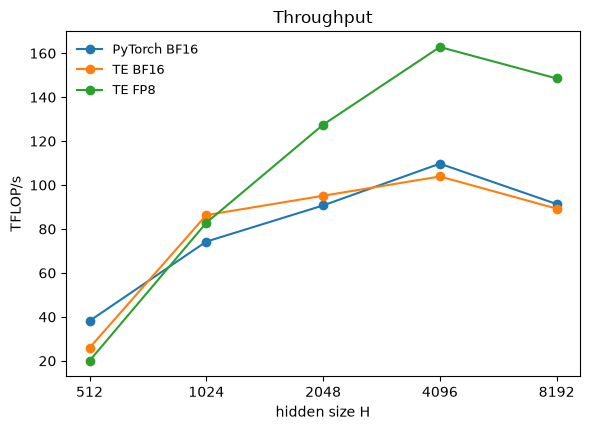

In [11]:
fig = plt.figure(1, (6, 4.4))

h = [r["hidden"] for r in rows]
for i, (key, label) in enumerate([("torch_bf16", "PyTorch BF16"), ("te_bf16", "TE BF16"), ("te_fp8", "TE FP8")]):
    plt.plot(h, [r[key] for r in rows], marker="o", label=label)
plt.xscale("log", base=2)
plt.xticks(h,h)
plt.xlabel("hidden size H")
plt.ylabel("TFLOP/s")
plt.title("Throughput")
plt.legend(frameon=False, fontsize=9)
fig.tight_layout()

### How to read this

**FP8 is faster at a size where compute dominates.** Below the crossover the same code that wins
at large `H` loses badly at small `H`, and it is the identical model with one context
manager changed.

The reason is that low precision only accelerates the *arithmetic*. The kernel launches, reading weights, and activations from memory are all still present.
The TE context also adds the extra work of potentially converting tensors to FP8, but always tracking their scale factors (even with bf16).
A small layer spends most of its time on those, so making the arithmetic cheaper barely moves the total.
A large layer spends most of its time multiplying (compute bound), so it has the largest effect.

**Look at the middle column too.** `te.Linear` in BF16 is *slower* than `nn.Linear` at the
smallest size, and only catches up as `H` grows. Transformer Engine carries fixed per-layer
bookkeeping that small layers cannot amortize. This is worth knowing before you reach for
it: "use Transformer Engine" is not free, and it can cost you on a small model.

Both effects have the same shape, and it is the single most useful idea in this workshop:
*low precision speeds up arithmetic, so it helps exactly as much as your arithmetic
dominates.*

## 0.5 What about batch size?

Hidden size is one dimension of the matrix multiply. The other is how many rows go through
it. Does making the batch bigger help as much as making the layer wider?

In [12]:
print("H=4096, 8 layers -- varying the batch (throughput in TFLOP/s)\n")
print(f"{'batch':>7}{'BF16':>11}{'FP8':>11}{'speedup':>10}")
print("-" * 39)
for m in (256, 1024, 4096, 8192, 16384, 32768):
    a = step_tflops(4096, batch=m, fp8=False)
    b = step_tflops(4096, batch=m, fp8=True)
    print(f"{m:>7}{a:>11.1f}{b:>11.1f}{b / a:>9.2f}x")

H=4096, 8 layers -- varying the batch (throughput in TFLOP/s)

  batch       BF16        FP8   speedup
---------------------------------------
    256       46.0       43.8     0.95x
   1024       90.6      113.0     1.25x
   4096      100.1      151.7     1.51x
   8192      100.3      166.0     1.66x
  16384      106.0      171.4     1.62x
  32768      109.2      293.0     2.68x


Batch size has a crossover too -- but it behaves differently from width. Our original runs used a batch size of 8192, which was the max speedup.

Width kept paying: every time `H` doubled, the speedup went up again, right out to the
largest size measured. Batch size stops paying. It climbs steeply out of losing territory
to roughly 1.3x and then **flattens**: going from 4096 rows to 32768 rows, eight times the data per step, barely
moves it.

That is the difference between *shape* and *occupancy*. A wider layer makes each individual
matrix multiply more arithmetic-heavy, which is what FP8 accelerates. A bigger batch just
gives the GPU more of the same-shaped work; once there is enough to keep every unit busy,
more does not help.

The practical consequence: if your model is too small for FP8 to pay, a bigger batch will
take you to break-even and no further. Only a wider model keeps climbing.

## 0.6 The rule that decides whether FP8 runs at all

FP8 tensor cores work on tiles. If a matrix dimension does not divide evenly into those
tiles, Transformer Engine refuses the operation rather than running it slowly.

**For training, all three matrix dimensions:**

* M = batch x sequence
* K = in_features
* N = out features

**must be divisible by 16.** Below, only the batch changes -- by as little as two rows.

In [13]:
import textwrap


def why(exc):
    """Keep the part of TE's message that explains the rule.

    Some of these errors come from C++ and arrive prefixed with a source path and
    function name; the sentence after "Assertion failed:" is the readable part.
    """
    text = " ".join(str(exc).split())
    if "Assertion failed:" in text:
        text = text.split("Assertion failed:", 1)[1].strip()
    return text

for m in (8192, 8190, 8184, 8200):
    try:
        tf = step_tflops(4096, n_layers=4, batch=m, fp8=True, iters=5, repeats=1)
        print(f"  batch {m:>5}  (batch % 16 = {m % 16:>2})  ran    {tf:>6.1f} TFLOP/s")
    except Exception as e:
        print(f"  batch {m:>5}  (batch % 16 = {m % 16:>2})  REFUSED")
        for line in textwrap.wrap(why(e), 84):
            print(f"        {line}")

  batch  8192  (batch % 16 =  0)  ran     280.8 TFLOP/s
  batch  8190  (batch % 16 = 14)  REFUSED
        FP8 execution requires the product of all dimensions except the last to be divisible
        by 8 and the last dimension to be divisible by 16, but got tensor with dims=[8190,
        4096] (product of leading dims = 8190, last dim = 4096)
  batch  8184  (batch % 16 =  8)  REFUSED
        ret.lda % 16 == 0. Leading dimension requirement on A for FP8 GEMM. Caller must pad.
  batch  8200  (batch % 16 =  8)  REFUSED
        ret.lda % 16 == 0. Leading dimension requirement on A for FP8 GEMM. Caller must pad.


Two things to take from this.

* FP8 doesn't silently fall back to BF16 and underperform
* Mixed error messages:
    * For `8190` TE says the dimension must be divisible by 8
    * `8184` **is** divisible by 8 and still fails (??)
        * This is a difference between the forward pass (last dimension divisible by 16) and the backward pass (all dimensions divisble by 16) during training.
    * A shape can work perfectly in inference and be rejected the moment you call `.backward()`

**The numbers you pick matter.** `8192` works and `8190` does not. This is why model
dimensions in the rest of the workshop are multiples of 16, 64 or 128 rather than round
decimal numbers, and why we pad GPT-2's vocabulary of 50257 to 50304 in notebook 01.

## 0.7 Which FP8 recipes does this GPU support?

"FP8" is not one thing. A *recipe* decides how the scale factor that maps your values into
FP8's narrow range is chosen and how finely it is applied. Support is genuinely patchy, and
it is **not** simply a matter of how new the GPU is -- so ask at runtime rather than
assuming.

In [14]:
for name, (ok, why) in helpers.te_support().items():
    print(f"  {name:14s} {'yes' if ok else 'no '}   {why[:66]}")

print("\nComparing the ones available here (H=4096, batch 8192):\n")
base = step_tflops(4096, fp8=False)
print(f"  {'bf16':<10}{base:>8.1f} TFLOP/s{1.0:>9.2f}x")
for r in [n for n, (ok, _) in helpers.te_support().items() if ok]:
    v = step_tflops(4096, fp8=True, recipe=r)
    print(f"  {r:<10}{v:>8.1f} TFLOP/s{v / base:>9.2f}x")

  delayed        yes   
  current        yes   
  block          yes   
  block_rowwise  yes   
  mxfp8          no    Device compute capability 10.0 or higher required for MXFP8 execut
  nvfp4          no    Device compute capability 10.0 or higher required for NVFP4 execut

Comparing the ones available here (H=4096, batch 8192):

  bf16         186.8 TFLOP/s     1.00x
  delayed      292.1 TFLOP/s     1.56x
  current      291.0 TFLOP/s     1.56x
  block        289.3 TFLOP/s     1.55x
  block_rowwise   282.7 TFLOP/s     1.51x


`delayed` scaling picks the scale from a rolling history of recent maxima, so it costs
nothing extra to compute but is always reacting to slightly stale information. `current`
scaling computes the scale from the tensor being converted, right now -- more accurate,
but it has to read the tensor an extra time. Notebook 02 examines what each one costs in
*accuracy*; here you can see what they cost in speed.

## Exercises

1. **Find your crossover.** Add `H = 768` and `H = 1536` to `SIZES` and re-run. Where exactly
   does FP8 break even on your GPU?
2. **Depth instead of width.** Does `n_layers=32` at `H=1024` behave like `n_layers=8` at
   `H=4096`? They do a similar number of FLOPs.
3. **Break it deliberately.** Make `hidden` a value that is not divisible by 16 and read the
   error. Which dimension does it complain about, and does it match the rule in 0.6?
4. **Forward only.** Delete the `.backward()` call from `step_tflops` and change the FLOP
   count from `6` to `2`. Does the speedup go up or down? Why might inference and training
   disagree about whether FP8 is worth it?
5. **Check the ceiling.** Divide your best FP8 TFLOP/s by the measured FP8 peak from 0.1.
   What fraction of the hardware are you actually using, and does it rise or fall with `H`?